# Ankh — Zinc Finger Prediction (Clean Pipeline)

Binary classification: **Zinc-finger** vs **Non-zinc-finger** proteins  
Model: **Ankh-base** (768-dim pooled embeddings)  
Classifiers: Logistic Regression + MLP  
Extra: Zinc-finger domain 21-mer window analysis using per-residue embeddings  
Output: `results_zinc_finger_Ankh/interpretation_report.html`

In [1]:
# ============================================================
# Cell 2 — Imports, SEED, device
# ============================================================
import random, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import umap as umap_lib
import base64

from pathlib import Path
from typing import Optional

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, roc_curve, auc,
    precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay, matthews_corrcoef,
    precision_score, recall_score,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
# ============================================================
# Cell 3 — Path resolution
# ============================================================
PROJECT_DIR = Path("__file__").resolve().parent if "__file__" in dir() else Path.cwd()
RESULTS_DIR = PROJECT_DIR / "results_zinc_finger_Ankh"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_ROOT  = PROJECT_DIR.parent.parent / "all_uniref"

CSV_FILE    = LOCAL_ROOT / "uniprotkb_AND_reviewed_true_AND_model_o_2026_01_16.tsv"
EMBED_FILE  = LOCAL_ROOT / "ankh_embedding_cache" / "pooled_embeddings.npz"
RESIDUE_DIR = LOCAL_ROOT / "ankh_embedding_cache"

print(f"Project dir  : {PROJECT_DIR}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"CSV file     : {CSV_FILE}  (exists: {CSV_FILE.exists()})")
print(f"Embedding    : {EMBED_FILE}  (exists: {EMBED_FILE.exists()})")
print(f"Residue dir  : {RESIDUE_DIR}  (exists: {RESIDUE_DIR.exists()})")

Project dir  : /home/saishyam/Protein_dynamics/zinc_finger_prediction/Clauge Agent Zinc finger
Results dir  : /home/saishyam/Protein_dynamics/zinc_finger_prediction/Clauge Agent Zinc finger/results_zinc_finger_Ankh
CSV file     : /home/saishyam/Protein_dynamics/all_uniref/uniprotkb_AND_reviewed_true_AND_model_o_2026_01_16.tsv  (exists: True)
Embedding    : /home/saishyam/Protein_dynamics/all_uniref/ankh_embedding_cache/pooled_embeddings.npz  (exists: True)
Residue dir  : /home/saishyam/Protein_dynamics/all_uniref/ankh_embedding_cache  (exists: True)


In [3]:
# ============================================================
# Cell 4 — Load CSV + build zinc-finger labels
# ============================================================
raw_df = pd.read_csv(CSV_FILE, sep="\t", low_memory=False)
print(f"Loaded {len(raw_df):,} rows from CSV")

# ---- Split zinc-finger (pos) / non-zinc-finger (neg) ----
pos_df = raw_df[raw_df["Zinc finger"].notna()].copy()
neg_df = raw_df[raw_df["Zinc finger"].isna()].copy()

pos_df = pos_df[["Entry", "Protein names", "Sequence", "Zinc finger"]].rename(
    columns={"Entry": "protein_id", "Protein names": "protein_name", "Sequence": "sequence"})
neg_df = neg_df[["Entry", "Protein names", "Sequence"]].rename(
    columns={"Entry": "protein_id", "Protein names": "protein_name", "Sequence": "sequence"})

pos_df = pos_df.drop_duplicates(subset="protein_name", keep="first")
neg_df = neg_df.drop_duplicates(subset="protein_name", keep="first")
overlap = set(pos_df["protein_name"]) & set(neg_df["protein_name"])
pos_df = pos_df[~pos_df["protein_name"].isin(overlap)].reset_index(drop=True)
neg_df = neg_df[~neg_df["protein_name"].isin(overlap)].reset_index(drop=True)

pos_df["label"] = 1
neg_df["label"] = 0

all_df = pd.concat([pos_df[["protein_id","protein_name","sequence","label"]],
                    neg_df[["protein_id","protein_name","sequence","label"]]], ignore_index=True)

assert pos_df["protein_name"].is_unique
assert neg_df["protein_name"].is_unique
assert set(pos_df["protein_name"]).isdisjoint(set(neg_df["protein_name"]))

print(f"Zinc-finger (pos) : {len(pos_df):,}")
print(f"Non-zinc-finger   : {len(neg_df):,}")
print(f"Imbalance ratio   : 1 : {len(neg_df)/len(pos_df):.1f}")
display(all_df["label"].value_counts().rename({1: "Zinc-finger", 0: "Non-zinc-finger"}).rename("count").to_frame())

Loaded 18,459 rows from CSV
Zinc-finger (pos) : 1,732
Non-zinc-finger   : 16,727
Imbalance ratio   : 1 : 9.7


,count
label,
Non-zinc-finger,16727
Zinc-finger,1732


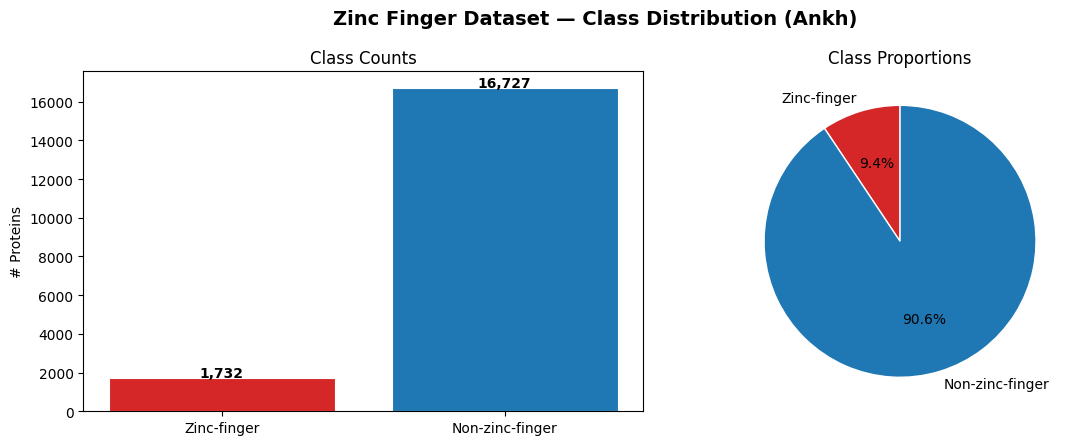

Saved: /home/saishyam/Protein_dynamics/zinc_finger_prediction/Clauge Agent Zinc finger/results_zinc_finger_Ankh/class_distribution.png


In [4]:
# ============================================================
# Cell 5 — Class distribution & imbalance visualisation
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

counts = [len(pos_df), len(neg_df)]
labels = ["Zinc-finger", "Non-zinc-finger"]
colors = ["#d62728", "#1f77b4"]
axes[0].bar(labels, counts, color=colors, edgecolor="white", linewidth=0.8)
for i, v in enumerate(counts):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")
axes[0].set_ylabel("# Proteins")
axes[0].set_title("Class Counts")

axes[1].pie(counts, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Class Proportions")

plt.suptitle("Zinc Finger Dataset — Class Distribution (Ankh)", fontsize=14, fontweight="bold")
plt.tight_layout()
fig_dist = RESULTS_DIR / "class_distribution.png"
plt.savefig(fig_dist, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_dist}")

In [5]:
# ============================================================
# Cell 6 — Load pooled Ankh embeddings (fast path)
# ============================================================
print(f"Loading Ankh embeddings from: {EMBED_FILE}")
t0 = time.perf_counter()
cache     = np.load(EMBED_FILE, allow_pickle=True)
max_pool  = cache["max"].item()   # dict: protein_id → ndarray (768,)
attn_pool = cache["attn"].item()  # dict: protein_id → ndarray (768,)
print(f"Loaded in {time.perf_counter()-t0:.1f}s")

def collect_embeddings(df, pool_dict):
    X, ids, labs = [], [], []
    miss = 0
    for _, row in df.iterrows():
        pid = row["protein_id"]
        if pid in pool_dict:
            X.append(pool_dict[pid])
            ids.append(pid)
            labs.append(row["label"])
        else:
            miss += 1
    if miss > 0:
        print(f"  Missing embeddings: {miss} proteins skipped")
    return np.stack(X).astype(np.float32), ids, np.array(labs)

X_max_pos,  _, _ = collect_embeddings(pos_df.assign(label=1), max_pool)
X_max_neg,  _, _ = collect_embeddings(neg_df.assign(label=0), max_pool)
X_attn_pos, _, _ = collect_embeddings(pos_df.assign(label=1), attn_pool)
X_attn_neg, _, _ = collect_embeddings(neg_df.assign(label=0), attn_pool)

emb_dim = X_max_pos.shape[1]
assert emb_dim == 768, f"Expected 768-dim, got {emb_dim}"

X_max  = np.vstack([X_max_pos,  X_max_neg])
X_attn = np.vstack([X_attn_pos, X_attn_neg])
y_bin  = np.array([1]*len(X_max_pos) + [0]*len(X_max_neg))

print(f"Max-pool   shape : {X_max.shape}")
print(f"Attn-pool  shape : {X_attn.shape}")
print(f"Labels     shape : {y_bin.shape}  |  positives: {y_bin.sum():,}  negatives: {(1-y_bin).sum():,}")
print(f"Embedding dim    : {emb_dim}")

Loading Ankh embeddings from: /home/saishyam/Protein_dynamics/all_uniref/ankh_embedding_cache/pooled_embeddings.npz
Loaded in 1.1s
Max-pool   shape : (18459, 768)
Attn-pool  shape : (18459, 768)
Labels     shape : (18459,)  |  positives: 1,732  negatives: 16,727
Embedding dim    : 768


In [6]:
# ============================================================
# Cell 7 — make_split / evaluate helpers + Logistic Regression
# ============================================================

def make_split(X, y):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED
    )
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr).astype(np.float32)
    Xte = sc.transform(Xte).astype(np.float32)
    return Xtr, Xte, ytr, yte, sc


def evaluate_binary(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    roc    = roc_auc_score(y_true, y_pred_proba)
    pr     = average_precision_score(y_true, y_pred_proba)
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, zero_division=0)
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score(y_true, y_pred, zero_division=0)
    mcc    = matthews_corrcoef(y_true, y_pred)
    fpr, tpr, _     = roc_curve(y_true, y_pred_proba)
    pre_c, rec_c, _ = precision_recall_curve(y_true, y_pred_proba)
    return dict(
        roc_auc=roc, pr_auc=pr, accuracy=acc, f1=f1,
        precision=prec, recall=rec, mcc=mcc,
        fpr=fpr, tpr=tpr, pre_c=pre_c, rec_c=rec_c,
        y_pred=y_pred, y_true=y_true, y_proba=y_pred_proba,
        n_test=len(y_true),
    )


results_store = {}
t0 = time.perf_counter()

for pool_name, X in [("max", X_max), ("attn", X_attn)]:
    Xtr, Xte, ytr, yte, _ = make_split(X, y_bin)
    clf = LogisticRegression(max_iter=5000, class_weight="balanced", n_jobs=-1, random_state=SEED)
    clf.fit(Xtr, ytr)
    proba = clf.predict_proba(Xte)[:, 1]
    results_store[("logistic_regression", pool_name)] = evaluate_binary(yte, proba)
    print(f"LR | {pool_name:4s} → ROC-AUC={results_store[('logistic_regression',pool_name)]['roc_auc']:.4f}  "
          f"PR-AUC={results_store[('logistic_regression',pool_name)]['pr_auc']:.4f}  "
          f"F1={results_store[('logistic_regression',pool_name)]['f1']:.4f}  "
          f"MCC={results_store[('logistic_regression',pool_name)]['mcc']:.4f}")

print(f"\nLogistic Regression complete in {time.perf_counter()-t0:.1f}s")

LR | max  → ROC-AUC=0.9775  PR-AUC=0.8982  F1=0.8021  MCC=0.7830
LR | attn → ROC-AUC=0.9871  PR-AUC=0.9380  F1=0.8629  MCC=0.8502

Logistic Regression complete in 4.2s


In [7]:
# ============================================================
# Cell 8 — MLP (binary) + training
# ============================================================

class MLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


training_loss = {}


def train_mlp(X: np.ndarray, y: np.ndarray, epochs=30, lr=1e-3, batch=64):
    Xtr, Xte, ytr, yte, sc = make_split(X, y)
    ytr_f = ytr.astype(np.float32)

    n_pos = ytr_f.sum(); n_neg = len(ytr_f) - n_pos
    pos_weight = torch.tensor(n_neg / max(n_pos, 1), dtype=torch.float32).to(device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    model_m   = MLP(X.shape[1]).to(device)
    optimizer = torch.optim.Adam(model_m.parameters(), lr=lr)
    loader    = DataLoader(
        TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr_f)),
        batch_size=batch, shuffle=True,
    )

    losses = []
    model_m.train()
    for epoch in range(epochs):
        running = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model_m(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item()
        losses.append(running / len(loader))

    model_m.eval()
    with torch.no_grad():
        proba = torch.sigmoid(
            model_m(torch.from_numpy(Xte).to(device))
        ).cpu().numpy()

    return evaluate_binary(yte, proba), losses


t0 = time.perf_counter()
for pool_name, X in [("max", X_max), ("attn", X_attn)]:
    metrics, losses = train_mlp(X, y_bin)
    results_store[("mlp", pool_name)] = metrics
    training_loss[pool_name] = losses
    print(f"MLP | {pool_name:4s} → ROC-AUC={metrics['roc_auc']:.4f}  "
          f"PR-AUC={metrics['pr_auc']:.4f}  "
          f"F1={metrics['f1']:.4f}  "
          f"MCC={metrics['mcc']:.4f}")

print(f"\nMLP training complete in {time.perf_counter()-t0:.1f}s")

MLP | max  → ROC-AUC=0.9860  PR-AUC=0.9385  F1=0.8908  MCC=0.8796
MLP | attn → ROC-AUC=0.9904  PR-AUC=0.9406  F1=0.8788  MCC=0.8668

MLP training complete in 20.9s


In [8]:
# ============================================================
# Cell 9 — Results DataFrame + save CSV/MD
# ============================================================

rows = []
for (model_name, pool_name), m in results_store.items():
    rows.append(dict(
        model=model_name, pooling=pool_name,
        roc_auc=round(m["roc_auc"],   4),
        pr_auc=round(m["pr_auc"],     4),
        f1=round(m["f1"],             4),
        accuracy=round(m["accuracy"], 4),
        mcc=round(m["mcc"],           4),
        precision=round(m["precision"], 4),
        recall=round(m["recall"],     4),
        n_test=m["n_test"],
    ))

results_df = (
    pd.DataFrame(rows)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

results_df.to_csv(RESULTS_DIR / "summary_metrics.csv", index=False)
results_df.to_markdown(RESULTS_DIR / "summary_metrics.md", index=False)

print(f"Saved: {RESULTS_DIR}/summary_metrics.csv")
print(f"Saved: {RESULTS_DIR}/summary_metrics.md")

display(
    results_df.style
    .highlight_max(subset=["roc_auc","pr_auc","f1","mcc"], color="#d4f0c4")
    .format({c: "{:.4f}" for c in ["roc_auc","pr_auc","f1","accuracy","mcc","precision","recall"]})
)

Saved: /home/saishyam/Protein_dynamics/zinc_finger_prediction/Clauge Agent Zinc finger/results_zinc_finger_Ankh/summary_metrics.csv
Saved: /home/saishyam/Protein_dynamics/zinc_finger_prediction/Clauge Agent Zinc finger/results_zinc_finger_Ankh/summary_metrics.md


,model,pooling,roc_auc,pr_auc,f1,accuracy,mcc,precision,recall,n_test
0,mlp,attn,0.9904,0.9406,0.8788,0.9762,0.8668,0.8395,0.9220,3692
1,logistic_regression,attn,0.9871,0.9380,0.8629,0.9724,0.8502,0.8065,0.9277,3692
2,mlp,max,0.9860,0.9385,0.8908,0.9789,0.8796,0.8641,0.9191,3692
3,logistic_regression,max,0.9775,0.8982,0.8021,0.9596,0.7830,0.7420,0.8728,3692


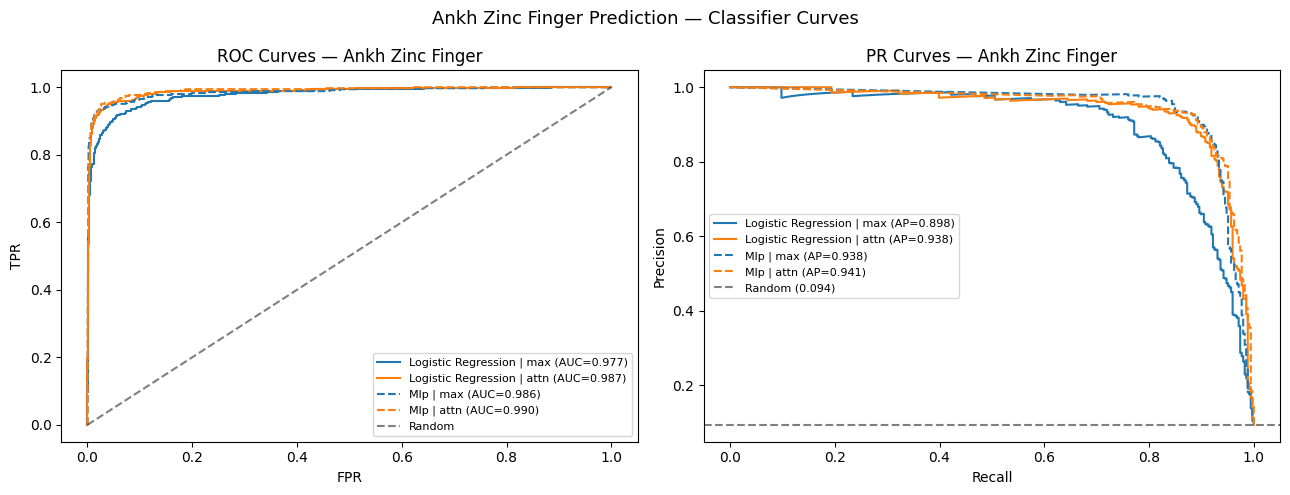

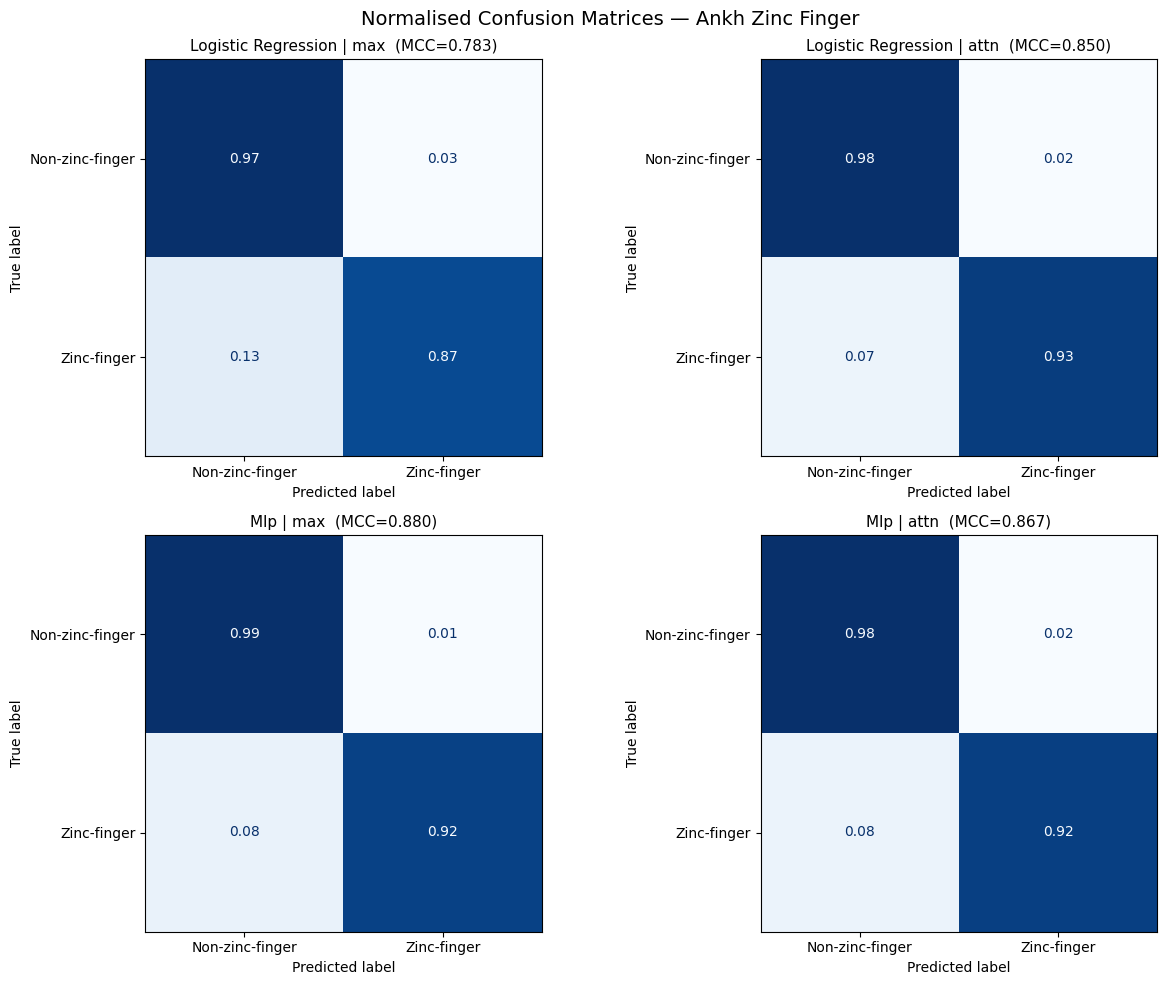

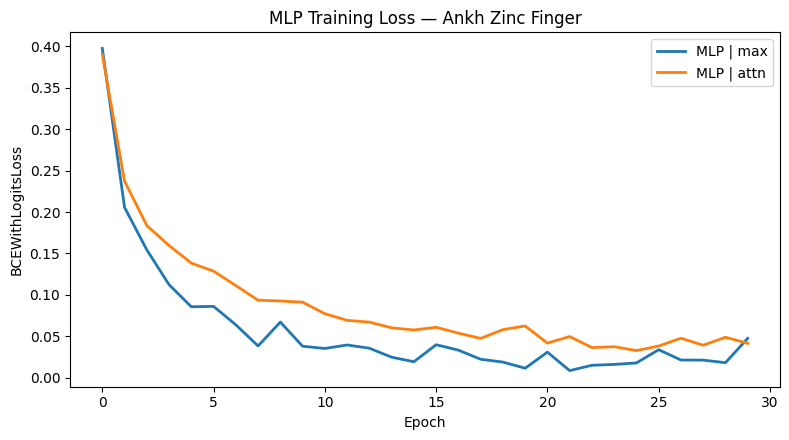

Saved: /home/saishyam/Protein_dynamics/zinc_finger_prediction/Clauge Agent Zinc finger/results_zinc_finger_Ankh/roc_pr_curves.png
Saved: /home/saishyam/Protein_dynamics/zinc_finger_prediction/Clauge Agent Zinc finger/results_zinc_finger_Ankh/confusion_matrices.png
Saved: /home/saishyam/Protein_dynamics/zinc_finger_prediction/Clauge Agent Zinc finger/results_zinc_finger_Ankh/mlp_training_loss.png


In [9]:
# ============================================================
# Cell 10 — ROC, PR curves, confusion matrices, MLP loss
# ============================================================

best_row = results_df.iloc[0]
best_key = (best_row["model"], best_row["pooling"])

# ---- ROC + PR curves ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_cfg = {"max": "#1f77b4", "attn": "#ff7f0e"}
styles_cfg = {"logistic_regression": "-", "mlp": "--"}

for (mn, pn), m in results_store.items():
    lbl = f"{mn.replace('_',' ').title()} | {pn} (AUC={m['roc_auc']:.3f})"
    axes[0].plot(m["fpr"], m["tpr"], linestyle=styles_cfg[mn],
                 color=colors_cfg[pn], label=lbl)
axes[0].plot([0,1],[0,1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curves — Ankh Zinc Finger")
axes[0].legend(fontsize=8)

baseline = y_bin.mean()
for (mn, pn), m in results_store.items():
    lbl = f"{mn.replace('_',' ').title()} | {pn} (AP={m['pr_auc']:.3f})"
    axes[1].plot(m["rec_c"], m["pre_c"], linestyle=styles_cfg[mn],
                 color=colors_cfg[pn], label=lbl)
axes[1].axhline(baseline, color="k", linestyle="--", alpha=0.5, label=f"Random ({baseline:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR Curves — Ankh Zinc Finger")
axes[1].legend(fontsize=8)

plt.suptitle("Ankh Zinc Finger Prediction — Classifier Curves", fontsize=13)
plt.tight_layout()
roc_path = RESULTS_DIR / "roc_pr_curves.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight"); plt.show()

# ---- Confusion matrices ----
keys_order = [
    ("logistic_regression", "max"),  ("logistic_regression", "attn"),
    ("mlp",                 "max"),  ("mlp",                 "attn"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, key in zip(axes.ravel(), keys_order):
    m  = results_store[key]
    cm = confusion_matrix(m["y_true"], m["y_pred"], normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=["Non-zinc-finger","Zinc-finger"]).plot(
        ax=ax, cmap="Blues", values_format=".2f", colorbar=False
    )
    ax.set_title(f"{key[0].replace('_',' ').title()} | {key[1]}  (MCC={results_store[key]['mcc']:.3f})", fontsize=11)

plt.suptitle("Normalised Confusion Matrices — Ankh Zinc Finger", fontsize=14)
plt.tight_layout()
cm_path = RESULTS_DIR / "confusion_matrices.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight"); plt.show()

# ---- MLP training loss ----
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(training_loss["max"],  label="MLP | max",  linewidth=2)
ax.plot(training_loss["attn"], label="MLP | attn", linewidth=2)
ax.set_title("MLP Training Loss — Ankh Zinc Finger")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCEWithLogitsLoss")
ax.legend(); plt.tight_layout()
loss_path = RESULTS_DIR / "mlp_training_loss.png"
plt.savefig(loss_path, dpi=300, bbox_inches="tight"); plt.show()

print(f"Saved: {roc_path}\nSaved: {cm_path}\nSaved: {loss_path}")

Visualising 5000 points (470 pos, 4530 neg)
t-SNE complete in 24.0s
UMAP complete in 22.5s


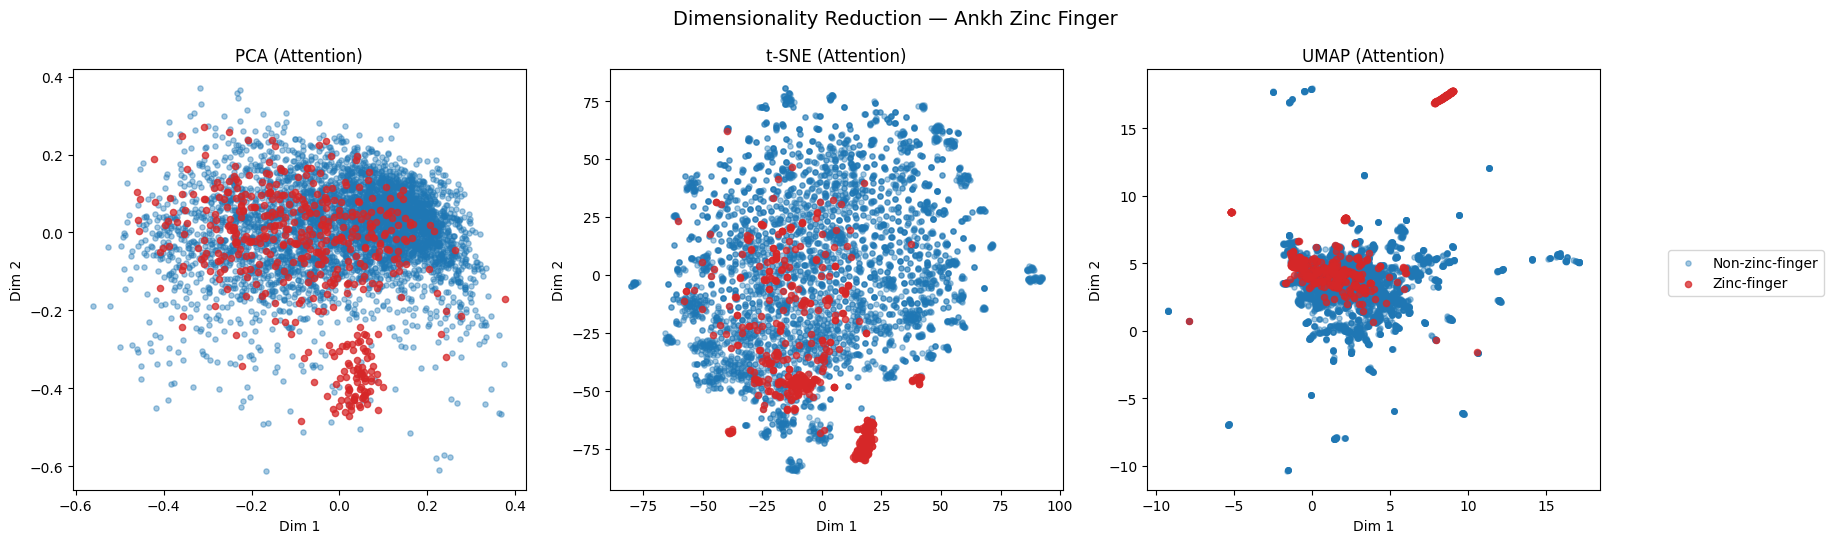

Saved: /home/saishyam/Protein_dynamics/zinc_finger_prediction/Clauge Agent Zinc finger/results_zinc_finger_Ankh/embedding_projection_pca_tsne_umap.png


In [10]:
# ============================================================
# Cell 11 — PCA + t-SNE + UMAP visualisation
# ============================================================
MAX_VIS = 5000
if len(X_attn) > MAX_VIS:
    rng     = np.random.default_rng(SEED)
    idx_pos = np.where(y_bin == 1)[0]
    idx_neg = np.where(y_bin == 0)[0]
    n_pos_v = min(len(idx_pos), int(MAX_VIS * len(idx_pos) / len(y_bin)) + 1)
    n_neg_v = MAX_VIS - n_pos_v
    idx = np.concatenate([
        rng.choice(idx_pos, size=n_pos_v, replace=False),
        rng.choice(idx_neg, size=n_neg_v, replace=False),
    ])
    X_vis = X_attn[idx]; y_vis = y_bin[idx]
    print(f"Visualising {MAX_VIS} points ({n_pos_v} pos, {n_neg_v} neg)")
else:
    X_vis, y_vis = X_attn, y_bin
    print(f"Visualising full dataset: {len(X_vis)} points")

pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(X_vis)

t0 = time.perf_counter()
tsne_2d = TSNE(n_components=2, init="pca", learning_rate="auto",
               perplexity=30, random_state=SEED).fit_transform(X_vis)
print(f"t-SNE complete in {time.perf_counter()-t0:.1f}s")

t0 = time.perf_counter()
umap_2d = umap_lib.UMAP(n_neighbors=15, min_dist=0.1,
                         metric="cosine", random_state=SEED).fit_transform(X_vis)
print(f"UMAP complete in {time.perf_counter()-t0:.1f}s")

class_colors = {0: "#1f77b4", 1: "#d62728"}
class_labels = {0: "Non-zinc-finger", 1: "Zinc-finger"}
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (title, emb) in zip(axes, [
    ("PCA (Attention)",   pca_2d),
    ("t-SNE (Attention)", tsne_2d),
    ("UMAP (Attention)",  umap_2d),
]):
    for cls in [0, 1]:
        mask = y_vis == cls
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   s=14 if cls == 0 else 20,
                   alpha=0.4 if cls == 0 else 0.75,
                   color=class_colors[cls], label=class_labels[cls],
                   zorder=1 if cls == 0 else 2)
    ax.set_title(title); ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")

handles, labs = axes[0].get_legend_handles_labels()
fig.legend(handles, labs, loc="center right", bbox_to_anchor=(1.02, 0.5), fontsize=10)
plt.suptitle("Dimensionality Reduction — Ankh Zinc Finger", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 1])
emb_path = RESULTS_DIR / "embedding_projection_pca_tsne_umap.png"
plt.savefig(emb_path, dpi=300, bbox_inches="tight"); plt.show()
print(f"Saved: {emb_path}")

In [11]:
# ============================================================
# Cell 12 — Analysis summary text file
# ============================================================
best_row = results_df.iloc[0]
summary_lines = [
    "ANALYSIS SUMMARY — Ankh Zinc Finger Prediction",
    "================================================",
    f"Best model by ROC-AUC: {best_row['model']} + {best_row['pooling']}",
    f"ROC-AUC   : {best_row['roc_auc']:.4f}",
    f"PR-AUC    : {best_row['pr_auc']:.4f}",
    f"F1 score  : {best_row['f1']:.4f}",
    f"Accuracy  : {best_row['accuracy']:.4f}",
    f"MCC       : {best_row['mcc']:.4f}",
    "",
    "Dataset:",
    f"  Zinc-finger proteins    : {len(pos_df):,}",
    f"  Non-zinc-finger proteins: {len(neg_df):,}",
    f"  Imbalance ratio         : ~1:{len(neg_df)//len(pos_df)}",
    "",
    "Interpretation:",
    "- ROC-AUC is the primary metric (class-agnostic ranking).",
    "- PR-AUC is secondary — critical for imbalanced binary tasks.",
    "- Ankh uses 768-dim embeddings (encoder-only, ankh-base).",
    "- Imbalance handled via BCEWithLogitsLoss pos_weight + LR class_weight=balanced.",
]
analysis_path = RESULTS_DIR / "analysis_summary.txt"
analysis_path.write_text("\n".join(summary_lines))
print("\n".join(summary_lines))
print(f"\nSaved: {analysis_path}")

ANALYSIS SUMMARY — Ankh Zinc Finger Prediction
Best model by ROC-AUC: mlp + attn
ROC-AUC   : 0.9904
PR-AUC    : 0.9406
F1 score  : 0.8788
Accuracy  : 0.9762
MCC       : 0.8668

Dataset:
  Zinc-finger proteins    : 1,732
  Non-zinc-finger proteins: 16,727
  Imbalance ratio         : ~1:9

Interpretation:
- ROC-AUC is the primary metric (class-agnostic ranking).
- PR-AUC is secondary — critical for imbalanced binary tasks.
- Ankh uses 768-dim embeddings (encoder-only, ankh-base).
- Imbalance handled via BCEWithLogitsLoss pos_weight + LR class_weight=balanced.

Saved: /home/saishyam/Protein_dynamics/zinc_finger_prediction/Clauge Agent Zinc finger/results_zinc_finger_Ankh/analysis_summary.txt


In [12]:
# ============================================================
# Cell 13 — Zinc-finger domain 21-mer window dataset
# Per-residue Ankh embeddings (.pt files, shape L×768)
# ============================================================
import re

WINDOW       = 21
HALF         = WINDOW // 2
NEG_PER_PROT = 3


def load_residue_emb(pid: str) -> Optional[np.ndarray]:
    path = RESIDUE_DIR / f"{pid}.pt"
    if not path.exists():
        return None
    emb = torch.load(path, map_location="cpu")
    E   = emb if isinstance(emb, torch.Tensor) else emb["embeddings"]
    arr = E.cpu().numpy()
    assert arr.ndim == 2
    return arr


def extract_window(E: np.ndarray, center_1based: int) -> Optional[np.ndarray]:
    c = int(center_1based) - 1
    s, e = c - HALF, c + HALF + 1
    if s < 0 or e > E.shape[0]:
        return None
    return E[s:e].mean(axis=0)


def sample_neg_windows(E: np.ndarray, center_1based: int, k: int = 3) -> list:
    c = int(center_1based) - 1
    forbidden = set(range(c - HALF, c + HALF + 1))
    valid  = [i for i in range(HALF, E.shape[0] - HALF) if i not in forbidden]
    chosen = random.sample(valid, k=min(k, len(valid))) if valid else []
    return [E[i - HALF : i + HALF + 1].mean(axis=0) for i in chosen]


def parse_zf_domain_center(text) -> Optional[int]:
    """Parse first ZN_FING start..end and return its midpoint (1-based)."""
    if pd.isna(text):
        return None
    m = re.search(r"ZN_FING\s+(\d+)\.\.(\d+)", str(text))
    if m:
        start, end = int(m.group(1)), int(m.group(2))
        return (start + end) // 2
    nums = re.findall(r"\d+", str(text))
    return int(nums[0]) if nums else None


raw_pos = raw_df[raw_df["Zinc finger"].notna()].copy()
raw_pos["domain_center"] = raw_pos["Zinc finger"].apply(parse_zf_domain_center)
dom_df = (
    raw_pos[raw_pos["domain_center"].notna()]
    .loc[:, ["Entry", "domain_center"]]
    .rename(columns={"Entry": "protein_id"})
    .drop_duplicates(subset="protein_id", keep="first")
    .reset_index(drop=True)
)
print(f"Zinc-finger proteins with domain position: {len(dom_df):,}")

X_win, y_win = [], []
skipped = 0
t0 = time.perf_counter()

# Positive proteins: domain window + non-domain windows (label=1)
for _, row in dom_df.iterrows():
    pid    = row["protein_id"]
    center = row["domain_center"]
    E = load_residue_emb(pid)
    if E is None:
        skipped += 1; continue
    w = extract_window(E, center)
    if w is None:
        skipped += 1; continue
    X_win.append(w);  y_win.append(1)
    for w_neg in sample_neg_windows(E, center, k=NEG_PER_PROT):
        X_win.append(w_neg);  y_win.append(1)

# Negative proteins: random windows from non-zinc-finger proteins (label=0)
rng_win      = np.random.default_rng(SEED)
neg_pids     = neg_df["protein_id"].tolist()
rng_win.shuffle(neg_pids)
n_neg_target = len(dom_df) * (1 + NEG_PER_PROT)
added_neg    = 0
for pid in neg_pids:
    if added_neg >= n_neg_target:
        break
    E = load_residue_emb(pid)
    if E is None or E.shape[0] < WINDOW:
        continue
    center = rng_win.integers(HALF, E.shape[0] - HALF)
    w = E[center - HALF : center + HALF + 1].mean(axis=0)
    X_win.append(w);  y_win.append(0)
    added_neg += 1

X_win = np.vstack(X_win).astype(np.float32)
y_win = np.array(y_win)

print(f"Dataset built in {time.perf_counter()-t0:.1f}s")
print(f"Total windows : {len(X_win):,}  ({skipped} proteins skipped)")
print(f"Positives     : {(y_win==1).sum():,}  |  Negatives: {(y_win==0).sum():,}")
print(f"Window dim    : {X_win.shape[1]}")

Zinc-finger proteins with domain position: 1,732
Dataset built in 30.2s
Total windows : 13,600  (64 proteins skipped)
Positives     : 6,672  |  Negatives: 6,928
Window dim    : 768


Domain window MLP trained in 7.1s

=== Zinc-finger Domain 21-mer Window MLP ===
ROC-AUC  : 0.9693
PR-AUC   : 0.9690
F1       : 0.9108
MCC      : 0.8243


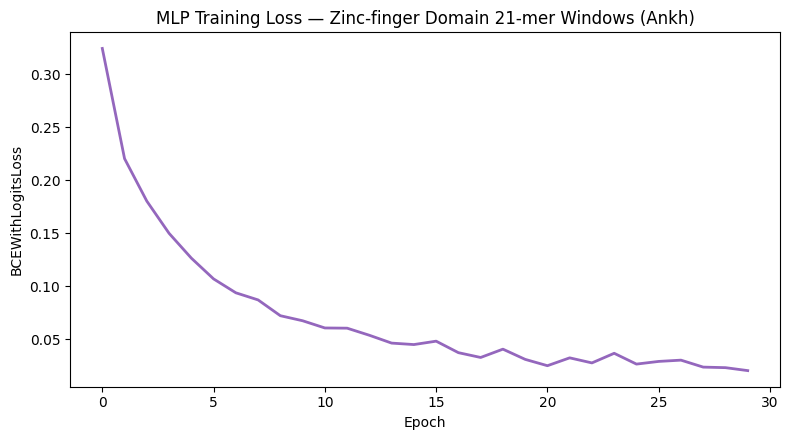

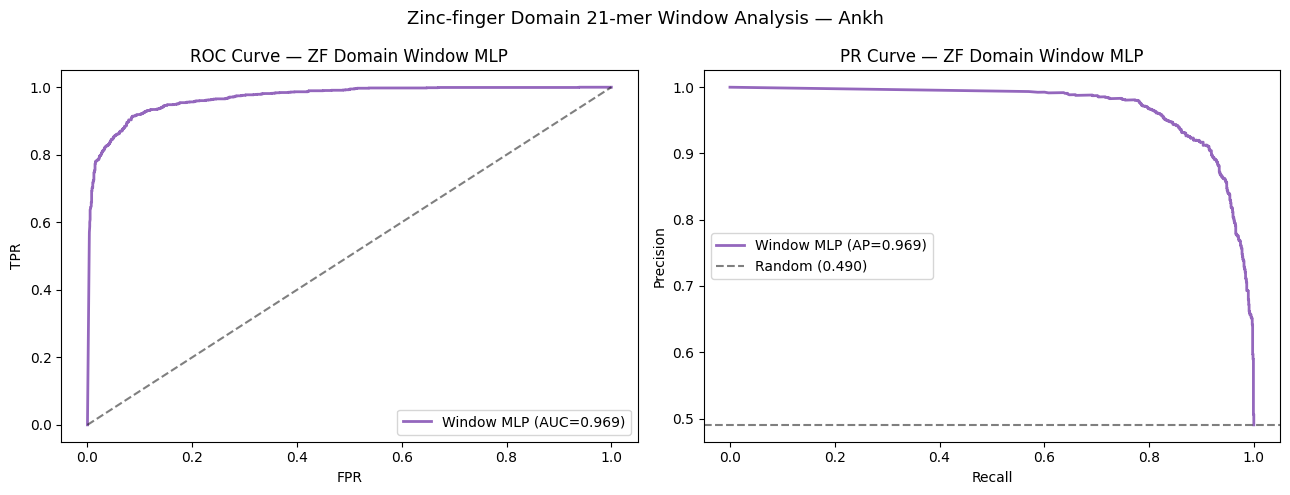

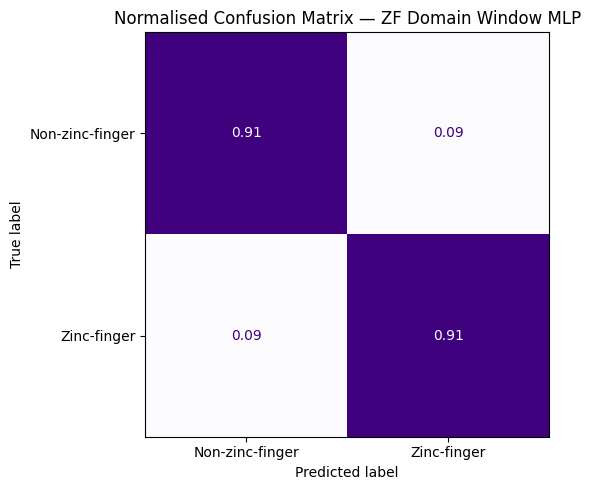

Saved: /home/saishyam/Protein_dynamics/zinc_finger_prediction/Clauge Agent Zinc finger/results_zinc_finger_Ankh/domain_window_training_loss.png
Saved: /home/saishyam/Protein_dynamics/zinc_finger_prediction/Clauge Agent Zinc finger/results_zinc_finger_Ankh/domain_window_roc_pr.png
Saved: /home/saishyam/Protein_dynamics/zinc_finger_prediction/Clauge Agent Zinc finger/results_zinc_finger_Ankh/domain_window_confusion_matrix.png


In [13]:
# ============================================================
# Cell 14 — Zinc-finger domain window MLP + evaluation + plots
# ============================================================

class MLP_bin(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64),        nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


Xtr_w, Xte_w, ytr_w, yte_w, sc_w = make_split(X_win, y_win)
ytr_wf = ytr_w.astype(np.float32)

n_pos_w = ytr_wf.sum(); n_neg_w = len(ytr_wf) - n_pos_w
pw_w    = torch.tensor(n_neg_w / max(n_pos_w, 1), dtype=torch.float32).to(device)
crit_w  = nn.BCEWithLogitsLoss(pos_weight=pw_w)

win_model = MLP_bin(X_win.shape[1]).to(device)
opt_w     = torch.optim.Adam(win_model.parameters(), lr=1e-3)
loader_w  = DataLoader(
    TensorDataset(torch.from_numpy(Xtr_w), torch.from_numpy(ytr_wf)),
    batch_size=64, shuffle=True,
)

win_losses = []
t0 = time.perf_counter()
win_model.train()
for epoch in range(30):
    running = 0.0
    for xb, yb in loader_w:
        xb, yb = xb.to(device), yb.to(device)
        opt_w.zero_grad()
        loss = crit_w(win_model(xb), yb)
        loss.backward()
        opt_w.step()
        running += loss.item()
    win_losses.append(running / len(loader_w))
print(f"Domain window MLP trained in {time.perf_counter()-t0:.1f}s")

win_model.eval()
with torch.no_grad():
    win_proba = torch.sigmoid(
        win_model(torch.from_numpy(Xte_w).to(device))
    ).cpu().numpy()

wm = evaluate_binary(yte_w, win_proba)
print(f"\n=== Zinc-finger Domain 21-mer Window MLP ===")
print(f"ROC-AUC  : {wm['roc_auc']:.4f}")
print(f"PR-AUC   : {wm['pr_auc']:.4f}")
print(f"F1       : {wm['f1']:.4f}")
print(f"MCC      : {wm['mcc']:.4f}")

# ---- Training loss ----
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(win_losses, linewidth=2, color="#9467bd")
ax.set_title("MLP Training Loss — Zinc-finger Domain 21-mer Windows (Ankh)")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCEWithLogitsLoss")
plt.tight_layout()
wloss_path = RESULTS_DIR / "domain_window_training_loss.png"
plt.savefig(wloss_path, dpi=300, bbox_inches="tight"); plt.show()

# ---- ROC + PR ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(wm["fpr"], wm["tpr"], color="#9467bd", linewidth=2,
             label=f"Window MLP (AUC={wm['roc_auc']:.3f})")
axes[0].plot([0,1],[0,1],"k--",alpha=0.5)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve — ZF Domain Window MLP"); axes[0].legend()

axes[1].plot(wm["rec_c"], wm["pre_c"], color="#9467bd", linewidth=2,
             label=f"Window MLP (AP={wm['pr_auc']:.3f})")
axes[1].axhline(yte_w.mean(), color="k", linestyle="--", alpha=0.5,
                label=f"Random ({yte_w.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR Curve — ZF Domain Window MLP"); axes[1].legend()

plt.suptitle("Zinc-finger Domain 21-mer Window Analysis — Ankh", fontsize=13)
plt.tight_layout()
wroc_path = RESULTS_DIR / "domain_window_roc_pr.png"
plt.savefig(wroc_path, dpi=300, bbox_inches="tight"); plt.show()

# ---- Confusion matrix ----
fig, ax = plt.subplots(figsize=(6, 5))
cm_w = confusion_matrix(wm["y_true"], wm["y_pred"], normalize="true")
ConfusionMatrixDisplay(cm_w, display_labels=["Non-zinc-finger","Zinc-finger"]).plot(
    ax=ax, cmap="Purples", values_format=".2f", colorbar=False
)
ax.set_title("Normalised Confusion Matrix — ZF Domain Window MLP")
plt.tight_layout()
wcm_path = RESULTS_DIR / "domain_window_confusion_matrix.png"
plt.savefig(wcm_path, dpi=300, bbox_inches="tight"); plt.show()

print(f"Saved: {wloss_path}\nSaved: {wroc_path}\nSaved: {wcm_path}")

In [14]:
# ============================================================
# Cell 15 — HTML interpretation report
# ============================================================

def img_to_b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()


best_row = results_df.iloc[0]
best_key = (best_row["model"], best_row["pooling"])
n_total  = len(pos_df) + len(neg_df)
n_test   = int(best_row["n_test"])
baseline = len(pos_df) / n_total


def fmt_row(idx, r):
    m  = r["model"].replace("_", " ").title()
    p  = r["pooling"].upper()
    bg = ' style="background:#fff9e6"' if idx == 0 else ""
    return (
        f"<tr{bg}>"
        f"<td>{m}</td><td>{p}</td>"
        f"<td><b>{r['roc_auc']:.4f}</b></td>"
        f"<td>{r['pr_auc']:.4f}</td>"
        f"<td>{r['f1']:.4f}</td>"
        f"<td>{r['mcc']:.4f}</td>"
        f"<td>{r['accuracy']:.4f}</td>"
        f"<td>{r['n_test']}</td>"
        f"</tr>"
    )

table_rows = "\n".join(fmt_row(i, r) for i, (_, r) in enumerate(results_df.iterrows()))

fig_dist  = img_to_b64(RESULTS_DIR / "class_distribution.png")
fig_roc   = img_to_b64(RESULTS_DIR / "roc_pr_curves.png")
fig_cm    = img_to_b64(RESULTS_DIR / "confusion_matrices.png")
fig_loss  = img_to_b64(RESULTS_DIR / "mlp_training_loss.png")
fig_emb   = img_to_b64(RESULTS_DIR / "embedding_projection_pca_tsne_umap.png")
fig_wloss = img_to_b64(RESULTS_DIR / "domain_window_training_loss.png")
fig_wroc  = img_to_b64(RESULTS_DIR / "domain_window_roc_pr.png")
fig_wcm   = img_to_b64(RESULTS_DIR / "domain_window_confusion_matrix.png")

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Ankh Zinc Finger Prediction &mdash; Interpretation Report</title>
<style>
  body  {{ font-family: 'Segoe UI', Arial, sans-serif; max-width: 1100px; margin: 40px auto; padding: 0 30px; color: #222; line-height: 1.65; }}
  h1    {{ color: #1a3a5c; border-bottom: 3px solid #1a3a5c; padding-bottom: 8px; }}
  h2    {{ color: #2e6da4; margin-top: 42px; }}
  h3    {{ color: #444; margin-top: 24px; }}
  table {{ border-collapse: collapse; width: 100%; margin: 14px 0; font-size: 0.93em; }}
  th    {{ background: #1a3a5c; color: #fff; padding: 8px 10px; text-align: left; }}
  td    {{ padding: 7px 10px; border: 1px solid #ddd; }}
  tr:nth-child(even) td {{ background: #f4f8ff; }}
  .metric-box {{ display: inline-block; background: #f0f6ff; border: 1px solid #b3cde0;
                 border-radius: 6px; padding: 12px 22px; margin: 8px 8px 8px 0;
                 text-align: center; min-width: 130px; vertical-align: top; }}
  .metric-box .val {{ font-size: 1.75em; font-weight: bold; color: #1a3a5c; }}
  .metric-box .lbl {{ font-size: 0.8em; color: #666; margin-top: 4px; }}
  img   {{ max-width: 100%; border: 1px solid #ddd; border-radius: 4px; display: block; margin: 12px auto; }}
  .caption {{ font-size: 0.85em; color: #555; text-align: center; margin-top: 4px; font-style: italic; }}
  .note  {{ background: #f9f9f9; border-left: 4px solid #2e6da4; padding: 10px 16px; margin: 16px 0; font-size: 0.93em; }}
  .note-green {{ background: #f2fdf4; border-left: 4px solid #27ae60; padding: 10px 16px; margin: 16px 0; font-size: 0.93em; }}
  .note-orange {{ background: #fff8f0; border-left: 4px solid #e67e22; padding: 10px 16px; margin: 16px 0; font-size: 0.93em; }}
  hr     {{ border: none; border-top: 1px solid #ddd; margin: 32px 0; }}
  code   {{ background: #f4f4f4; padding: 1px 5px; border-radius: 3px; font-size: 0.9em; }}
  .prot-badge {{ display:inline-block; background:#e3f2fd; border:1px solid #1976d2;
                 border-radius:4px; padding:2px 8px; font-size:0.85em; color:#0d47a1; font-weight:bold; }}
  .section-win {{ background:#f4f8ff; border: 1px solid #b3cde0; border-radius:6px;
                  padding: 18px 22px; margin: 24px 0; }}
</style>
</head>
<body>

<h1>Ankh Zinc Finger Prediction &mdash; Interpretation Report</h1>
<p style="color:#555; font-size:0.9em">
  Source: <code>Ankh_zinc_finger_clean_pipeline.ipynb</code> &nbsp;|&nbsp;
  Model: <span class="prot-badge">Ankh-base &bull; 768-dim</span> &nbsp;|&nbsp;
  Task: Binary classification (Zinc-finger vs Non-zinc-finger)
</p>

<hr>

<h2>1. Dataset</h2>
<p>UniProtKB Swiss-Prot reviewed proteins split by the <code>Zinc finger</code> annotation column:</p>
<ul>
  <li><b>Positive (Zinc-finger)</b>: proteins with at least one annotated <code>ZN_FING</code> feature</li>
  <li><b>Negative (non-zinc-finger)</b>: proteins with no zinc finger annotation</li>
  <li>Mutual exclusivity enforced &mdash; no protein appears in both sets</li>
  <li>Duplicate protein names removed (keep first)</li>
</ul>

<div class="note-orange">
  <b>Class Imbalance Warning:</b> The dataset is imbalanced (~1:{len(neg_df)//len(pos_df)} ratio).
  All classifiers use imbalance correction (LR: <code>class_weight=&quot;balanced&quot;</code>;
  MLP: <code>BCEWithLogitsLoss(pos_weight)</code>).
  PR-AUC is a more informative metric than ROC-AUC under imbalance.
</div>

<div>
  <div class="metric-box"><div class="val">{n_total:,}</div><div class="lbl">Total proteins</div></div>
  <div class="metric-box"><div class="val">{len(pos_df):,}</div><div class="lbl">Zinc-finger (pos)</div></div>
  <div class="metric-box"><div class="val">{len(neg_df):,}</div><div class="lbl">Non-zinc-finger</div></div>
  <div class="metric-box"><div class="val">{n_test:,}</div><div class="lbl">Test set (20%)</div></div>
  <div class="metric-box"><div class="val">{emb_dim}</div><div class="lbl">Embedding dim</div></div>
</div>

<img src="data:image/png;base64,{fig_dist}" style="max-width:700px">
<p class="caption">Figure 1. Class distribution.</p>

<hr>

<h2>2. Methods</h2>

<h3>2.1 Full-protein Pooled Embeddings</h3>
<p><b>Ankh-base</b> (Elnaggar et al., 2023) produces 768-dimensional per-residue representations,
aggregated to fixed-length protein vectors via:
</p>
<ul>
  <li><b>Max pooling</b> &mdash; element-wise maximum over residues</li>
  <li><b>Attention pooling</b> &mdash; learned weighted average over residues</li>
</ul>
<p>All features z-score normalised (StandardScaler fit on train only). 80/20 stratified split, seed {SEED}.</p>

<h3>2.2 Zinc-finger Domain 21-mer Window Embeddings</h3>
<p>
Per-residue Ankh embeddings (<code>.pt</code> files, shape L&times;768) are loaded for each protein.
A 21-residue window is centred on the midpoint of the first annotated UniProt <code>ZN_FING</code>
domain range and mean-pooled to a 768-dim vector.
Additionally, {NEG_PER_PROT} random non-domain windows from the same protein (positive label) are included,
and equal-count random windows from non-zinc-finger proteins (negative label) are added.
</p>
<table>
  <tr><th>Parameter</th><th>Value</th></tr>
  <tr><td>Window size</td><td>21 residues (10 on each side of domain midpoint)</td></tr>
  <tr><td>Pooling</td><td>Mean over window residues &rarr; 768-dim vector</td></tr>
  <tr><td>Non-domain windows per protein</td><td>{NEG_PER_PROT}</td></tr>
  <tr><td>Negative windows</td><td>Random windows from non-zinc-finger proteins</td></tr>
  <tr><td>Classifier</td><td>MLP: 768&rarr;256&rarr;64&rarr;1 (binary), 30 epochs, Adam lr=1e-3</td></tr>
</table>

<h3>2.3 Classifiers (full-protein)</h3>
<table>
  <tr><th>Model</th><th>Architecture</th><th>Imbalance handling</th></tr>
  <tr><td>Logistic Regression</td><td>L2 penalty, lbfgs, max_iter=5000</td><td>class_weight=&quot;balanced&quot;</td></tr>
  <tr><td>MLP (PyTorch)</td>
      <td>Linear(768&rarr;512)&rarr;ReLU&rarr;Dropout(0.3)&rarr;
          Linear(512&rarr;128)&rarr;ReLU&rarr;Dropout(0.3)&rarr;Linear(128&rarr;1),
          Adam lr=1e-3, 30 epochs, batch=64, BCEWithLogitsLoss</td>
      <td>pos_weight = n_neg / n_pos</td></tr>
</table>

<hr>

<h2>3. Full-protein Pooled Embedding Results</h2>

<h3>3.1 Performance Table</h3>
<p>All metrics on held-out test set. Row highlighted in yellow = best by ROC-AUC.
Random baseline PR-AUC &asymp; {baseline:.4f} (positive class fraction).</p>
<table>
  <tr>
    <th>Model</th><th>Pooling</th>
    <th>ROC-AUC &#9733;</th><th>PR-AUC</th><th>F1</th><th>MCC</th><th>Accuracy</th><th>N test</th>
  </tr>
  {table_rows}
</table>
<p class="caption">ROC-AUC = primary metric. PR-AUC = secondary (critical for imbalance).
MCC = Matthews Correlation Coefficient.</p>

<h3>3.2 Best Model Summary</h3>
<div>
  <div class="metric-box"><div class="val">{best_row['roc_auc']:.4f}</div><div class="lbl">ROC-AUC (primary)</div></div>
  <div class="metric-box"><div class="val">{best_row['pr_auc']:.4f}</div><div class="lbl">PR-AUC</div></div>
  <div class="metric-box"><div class="val">{best_row['f1']:.4f}</div><div class="lbl">F1 score</div></div>
  <div class="metric-box"><div class="val">{best_row['mcc']:.4f}</div><div class="lbl">MCC</div></div>
</div>
<p><b>Best configuration:</b> {best_row['model'].replace('_',' ').title()} + {best_row['pooling'].upper()} pooling</p>

<h3>Figure 2: ROC and PR Curves</h3>
<img src="data:image/png;base64,{fig_roc}">
<p class="caption">Figure 2. ROC (left) and Precision-Recall (right) curves for all 4 configurations.
Dashed horizontal line = random baseline for PR-AUC.</p>

<h3>Figure 3: Normalised Confusion Matrices</h3>
<img src="data:image/png;base64,{fig_cm}">
<p class="caption">Figure 3. Row-normalised confusion matrices for all 4 classifier configurations.</p>

<h3>Figure 4: MLP Training Loss</h3>
<img src="data:image/png;base64,{fig_loss}" style="max-width:640px">
<p class="caption">Figure 4. BCEWithLogitsLoss over 30 epochs for max (blue) and attention (orange) pooling.</p>

<h3>Figure 5: Embedding Space Visualisation</h3>
<img src="data:image/png;base64,{fig_emb}">
<p class="caption">Figure 5. PCA, t-SNE, and UMAP of Ankh attention embeddings coloured by class
(zinc-finger in red, non-zinc-finger in blue; up to {MAX_VIS} points shown).</p>

<hr>

<h2>4. Zinc-finger Domain 21-mer Window Analysis</h2>

<div class="section-win">
<p>
This analysis tests whether a 21-residue window centred on the annotated zinc-finger domain
(as defined by UniProt <code>ZN_FING</code> feature) carries sufficient discriminative signal
to distinguish zinc-finger from non-zinc-finger regions using only local sequence context.
Windows are mean-pooled from per-residue Ankh embeddings (L&times;768).
</p>
</div>

<div>
  <div class="metric-box"><div class="val">{wm['roc_auc']:.4f}</div><div class="lbl">ROC-AUC</div></div>
  <div class="metric-box"><div class="val">{wm['pr_auc']:.4f}</div><div class="lbl">PR-AUC</div></div>
  <div class="metric-box"><div class="val">{wm['f1']:.4f}</div><div class="lbl">F1 score</div></div>
  <div class="metric-box"><div class="val">{wm['mcc']:.4f}</div><div class="lbl">MCC</div></div>
  <div class="metric-box"><div class="val">21-mer</div><div class="lbl">Window size</div></div>
  <div class="metric-box"><div class="val">768</div><div class="lbl">Feature dim</div></div>
</div>

<h3>Figure 6: Domain Window MLP Training Loss</h3>
<img src="data:image/png;base64,{fig_wloss}" style="max-width:640px">
<p class="caption">Figure 6. BCEWithLogitsLoss over 30 epochs for domain window MLP.</p>

<h3>Figure 7: Domain Window ROC and PR Curves</h3>
<img src="data:image/png;base64,{fig_wroc}">
<p class="caption">Figure 7. ROC and PR curves for the domain window MLP.</p>

<h3>Figure 8: Domain Window Confusion Matrix</h3>
<img src="data:image/png;base64,{fig_wcm}" style="max-width:560px">
<p class="caption">Figure 8. Row-normalised confusion matrix for domain window MLP.</p>

<div class="note-green">
<b>Interpretation:</b>
Comparing the domain window ROC-AUC ({wm['roc_auc']:.4f}) to the full-protein best ({best_row['roc_auc']:.4f})
{'suggests the full-protein context provides additional discriminative power beyond the local zinc-finger domain.' if best_row['roc_auc'] > wm['roc_auc'] else 'shows the 21-mer domain window captures a comparable or stronger signal to full-protein embeddings.'}
{'A high domain window score indicates Ankh encodes distinct local chemistry around zinc-finger domains.' if wm['roc_auc'] > 0.7 else 'Domain-local information alone may be insufficient; global context is needed.'}
</div>

<hr>

<h2>5. Recommendations for Future Work</h2>
<ol>
  <li><b>Cross-validation:</b> Use 5-fold stratified CV to reduce variance from single splits.</li>
  <li><b>Hard negatives:</b> Use structurally similar non-zinc-finger proteins as hard negatives.</li>
  <li><b>All domains:</b> Use all annotated <code>ZN_FING</code> ranges per protein, not just the first.</li>
  <li><b>Window sweep:</b> Compare window sizes 11, 21, 41, 61 for optimal context.</li>
  <li><b>ESM2 / ProtT5 comparison:</b> See sibling notebooks for cross-model comparison.</li>
  <li><b>Fine-tuning:</b> End-to-end fine-tune Ankh for zinc-finger prediction.</li>
</ol>

<hr>

<h2>6. Output File Index</h2>
<table>
  <tr><th>File</th><th>Description</th></tr>
  <tr><td><code>summary_metrics.csv</code></td><td>Full-protein model metrics (machine-readable)</td></tr>
  <tr><td><code>summary_metrics.md</code></td><td>Markdown table of metrics</td></tr>
  <tr><td><code>analysis_summary.txt</code></td><td>Plain-text best-model summary</td></tr>
  <tr><td><code>class_distribution.png</code></td><td>Class counts and proportions</td></tr>
  <tr><td><code>roc_pr_curves.png</code></td><td>ROC + PR curves (all 4 full-protein configs)</td></tr>
  <tr><td><code>confusion_matrices.png</code></td><td>Normalised confusion matrices (4 configs)</td></tr>
  <tr><td><code>mlp_training_loss.png</code></td><td>BCEWithLogitsLoss — full-protein MLP</td></tr>
  <tr><td><code>embedding_projection_pca_tsne_umap.png</code></td><td>PCA / t-SNE / UMAP of Ankh attention embeddings</td></tr>
  <tr><td><code>domain_window_training_loss.png</code></td><td>Training loss — domain window MLP</td></tr>
  <tr><td><code>domain_window_roc_pr.png</code></td><td>ROC + PR — domain window MLP</td></tr>
  <tr><td><code>domain_window_confusion_matrix.png</code></td><td>Confusion matrix — domain window MLP</td></tr>
  <tr><td><code>interpretation_report.html</code></td><td>This report</td></tr>
</table>

<hr>
<p style="color:#888; font-size:0.82em">
  <b>To convert to .docx:</b> Open this .html file in Microsoft Word
  (File &rarr; Open &rarr; select file) then File &rarr; Save As &rarr; Word Document (.docx).
  Alternatively: open in browser &rarr; Print &rarr; Save as PDF.
</p>

</body>
</html>"""

report_path = RESULTS_DIR / "interpretation_report.html"
report_path.write_text(html, encoding="utf-8")
print(f"Saved: {report_path}")
print("\nTo convert to .docx:")
print("  Microsoft Word -> File -> Open -> select interpretation_report.html -> Save As -> .docx")

Saved: /home/saishyam/Protein_dynamics/zinc_finger_prediction/Clauge Agent Zinc finger/results_zinc_finger_Ankh/interpretation_report.html

To convert to .docx:
  Microsoft Word -> File -> Open -> select interpretation_report.html -> Save As -> .docx
